# Cross-Market Correlation Strategy: BTC & NASDAQ Futures


# 1. Project Understanding

## 1.1 Project Objective and Approach
This project aims to enhance the performance of a systematic trading strategy through the application of machine-learning techniques. A "baseline" rule-based strategy is first evaluated using historical backtesting to establish benchmark performance. Its limitations are then systematically analyzed, after which an appropriate machine-learning model is applied to address the identified weaknesses. The effectiveness of the proposed approach is evaluated by comparing trading performance before and after the integration of machine learning.

## 1.2 Hypothesis Definition
At short intraday time scales, directional agreement between Bitcoin (BTC) and NASDAQ-100 (NQ) futures reflects more stable market conditions, whereas directional divergence indicates increased market uncertainty and reduced trend persistence.


# 2. Data Understanding and Preparation

Goal: Explore, diagnose, and validate the raw data.

## 2.1 Data Sources and Structure
- **Assets:** BTCUSDT Perpetual Futures, NASDAQ-100 E-mini Futures  
- **Interval:** 1-minute OHLCV  
- **Period:** 1 Oct 2025 at 00:00:00 UTC – 12 Dec 2025 at 22:59:00 UTC  
- **Source:** TradingView
- **Columns:** timestamp, open, high, low, close, volume  
- **Market structure:** BTC trades 24/7, NQ trades during CME sessions

## 2.2 Timestamp Handling and Synchronization
0. Read and inspect CSVs

In [52]:
import pandas as pd

# Assuming 'Datasets' folder is in the same directory as the notebook
btc = pd.read_csv("Datasets/btc_raw_data.csv", sep=',')
nq  = pd.read_csv("Datasets/nq_raw_data.csv", sep=',')

# Inspect columns 
print("BTC Columns:", btc.columns)
print("BTC Head:\n", btc.head())
print("Total BTC rows:", len(btc))

print("\nNQ Columns:", nq.columns)
print("NQ Head:\n", nq.head())
print("Total NQ rows:", len(nq))


BTC Columns: Index(['time', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
BTC Head:
          time     open     high      low    close   volume
0  1704067200  42314.0  42335.8  42289.6  42331.9  289.641
1  1704067260  42331.9  42353.1  42331.8  42350.4  202.444
2  1704067320  42350.4  42370.8  42349.6  42360.2  271.521
3  1704067380  42360.1  42405.8  42360.1  42405.8  392.238
4  1704067440  42405.7  42437.2  42405.7  42437.1  568.366
Total BTC rows: 1015500

NQ Columns: Index(['time', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
NQ Head:
          time      open      high       low     close  volume
0  1704171720  16847.20  16855.68  16847.20  16854.66      49
1  1704171780  16854.66  16854.92  16853.68  16854.18      86
2  1704171840  16854.18  16855.05  16853.42  16854.91     146
3  1704171900  16854.91  16855.31  16854.18  16854.18     101
4  1704171960  16854.18  16854.30  16853.42  16853.93      49
Total NQ rows: 681646


1. Convert timestamps to datetime
2. Align both assets to the same timezone (UTC+1 / Polish time)
3. Synchronize datasets on common timestamps
4. Prepare the merged DataFrame for further analysis

In [53]:
# Convert UNIX epoch to datetime (assume UTC)
btc['timestamp'] = pd.to_datetime(btc['time'], unit='s', utc=True)
nq['timestamp']  = pd.to_datetime(nq['time'], unit='s', utc=True)

# Optional: convert to local time (Polish time UTC+1)
btc['timestamp'] = btc['timestamp'].dt.tz_convert('Europe/Warsaw')
nq['timestamp']  = nq['timestamp'].dt.tz_convert('Europe/Warsaw')

# Set timestamp as index
btc.set_index('timestamp', inplace=True)
nq.set_index('timestamp', inplace=True)

# Sort by timestamp just in case
btc.sort_index(inplace=True)
nq.sort_index(inplace=True)

# Keep only common timestamps for synchronized analysis
common_index = btc.index.intersection(nq.index)
btc_sync = btc.loc[common_index]
nq_sync  = nq.loc[common_index]

print("BTC synchronized head:\n", btc_sync.head())
print("NQ synchronized head:\n", nq_sync.head())
print("Total synchronized rows:", len(common_index))

print(btc_sync)
print(nq_sync.head)

BTC synchronized head:
                                  time     open     high      low    close  \
timestamp                                                                   
2024-01-02 06:02:00+01:00  1704171720  45183.1  45197.2  45183.1  45188.0   
2024-01-02 06:03:00+01:00  1704171780  45188.1  45194.1  45160.0  45184.9   
2024-01-02 06:04:00+01:00  1704171840  45184.7  45195.0  45153.0  45160.3   
2024-01-02 06:05:00+01:00  1704171900  45160.4  45183.9  45154.8  45182.9   
2024-01-02 06:06:00+01:00  1704171960  45182.8  45219.3  45180.1  45219.3   

                            volume  
timestamp                           
2024-01-02 06:02:00+01:00  117.864  
2024-01-02 06:03:00+01:00  208.659  
2024-01-02 06:04:00+01:00  231.227  
2024-01-02 06:05:00+01:00  145.061  
2024-01-02 06:06:00+01:00  207.322  
NQ synchronized head:
                                  time      open      high       low     close  \
timestamp                                                                

## 2.3 Data Quality Checks

In [54]:
import numpy as np
from scipy.stats import zscore

# 1. Check for missing values
print("BTC missing values per column:\n", btc_sync.isna().sum())
print("\nNQ missing values per column:\n", nq_sync.isna().sum())

# 2. Check for duplicated timestamps
print("\nDuplicated BTC timestamps:", btc_sync.index.duplicated().sum())
print("Duplicated NQ timestamps:", nq_sync.index.duplicated().sum())

# 3. Basic descriptive statistics(Close prices)
print("\nBTC descriptive statistics (Close):\n", btc_sync['close'].describe())
print("\nNQ descriptive statistics (Close):\n", nq_sync['close'].describe())

# 4. Outlier detection on log returns

# Compute log returns FIRST (needed for diagnostics)
btc_sync['return'] = np.log(btc_sync['close']).diff()
nq_sync['return']  = np.log(nq_sync['close']).diff()

# Drop NaNs created by diff()
btc_ret = btc_sync['return'].dropna()
nq_ret  = nq_sync['return'].dropna()

# Z-score based outlier check (|z| > 4)
btc_outliers = (np.abs(zscore(btc_ret)) > 4).sum()
nq_outliers  = (np.abs(zscore(nq_ret)) > 4).sum()

print("\nExtreme return outliers (|z| > 4):")
print(f"BTC: {btc_outliers}")
print(f"NQ : {nq_outliers}")


BTC missing values per column:
 time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

NQ missing values per column:
 time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Duplicated BTC timestamps: 0
Duplicated NQ timestamps: 0

BTC descriptive statistics (Close):
 count    681646.000000
mean      83557.268849
std       22730.080155
min       38560.600000
25%       63770.325000
50%       84995.950000
75%      104522.900000
max      126086.800000
Name: close, dtype: float64

NQ descriptive statistics (Close):
 count    681646.000000
mean      20670.817629
std        2385.485779
min       16191.040000
25%       18692.802500
50%       20294.230000
75%       22033.345000
max       26283.220000
Name: close, dtype: float64

Extreme return outliers (|z| > 4):
BTC: 3533
NQ : 5132


In [55]:
#OPTIONAL: Save final datasets
save_final = True  # Set to False if you don't want to save

if save_final:
    btc_final_path = "Datasets/btc_final.csv"
    nq_final_path = "Datasets/nq_final.csv"
    
    # Save synchronized and processed datasets
    btc_sync.to_csv(btc_final_path)
    nq_sync.to_csv(nq_final_path)
    
    print(f"BTC final synchronized dataset saved to {btc_final_path}")
    print(f"NQ final synchronized dataset saved to {nq_final_path}")
    print("Total synchronized rows saved:", len(common_index))

BTC final synchronized dataset saved to Datasets/btc_final.csv
NQ final synchronized dataset saved to Datasets/nq_final.csv
Total synchronized rows saved: 681646


## 2.4 Return Computation

Merged Returns Head:
                            BTC_return  NQ_return
timestamp                                       
2024-01-02 06:03:00+01:00   -0.000069  -0.000028
2024-01-02 06:04:00+01:00   -0.000545   0.000043
2024-01-02 06:05:00+01:00    0.000500  -0.000043
2024-01-02 06:06:00+01:00    0.000805  -0.000015
2024-01-02 06:07:00+01:00    0.000601  -0.000082
Merged Returns Description:
          BTC_return     NQ_return
count  6.816450e+05  6.816450e+05
mean   9.980178e-07  6.190295e-07
std    8.360358e-04  3.491415e-04
min   -6.649761e-02 -4.698573e-02
25%   -3.442050e-04 -1.015354e-04
50%    0.000000e+00  0.000000e+00
75%    3.451779e-04  1.074078e-04
max    1.136793e-01  2.682197e-02
Total rows after dropna: 681645


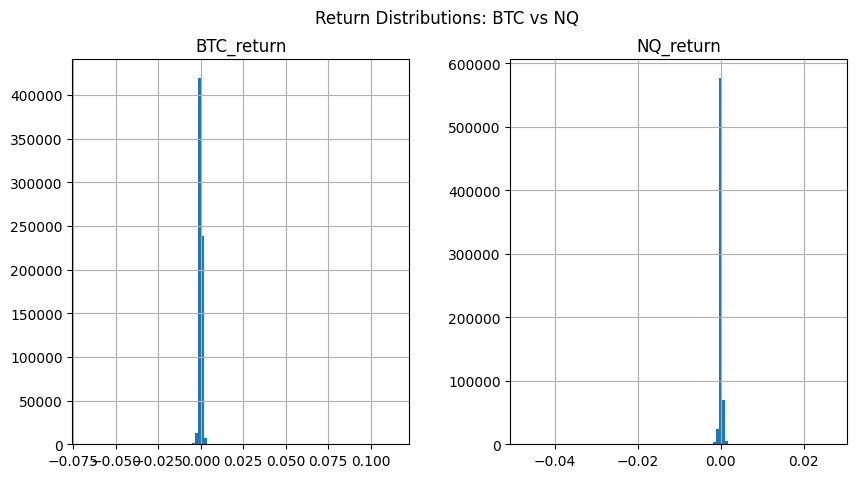

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Compute 1-minute log returns
btc_sync['return'] = np.log(btc_sync['close']).diff()
nq_sync['return']  = np.log(nq_sync['close']).diff()

# Merge returns into a single DataFrame
returns = pd.DataFrame({
    'BTC_return': btc_sync['return'],
    'NQ_return': nq_sync['return']
}).dropna()  # remove first row with NaN due to diff()

# Quick sanity check
print("Merged Returns Head:\n", returns.head())

# Save description to a variable
desc = returns.describe()
print("Merged Returns Description:\n", desc)
print("Total rows after dropna:", len(returns))

# Histogram
returns.hist(bins=100, figsize=(10,5))
plt.suptitle("Return Distributions: BTC vs NQ")
plt.show()

In [57]:
# Interpretation
print("\nData Interpretation based on outputs:")

# Volatility comparison
btc_std = desc.loc['std', 'BTC_return']
nq_std  = desc.loc['std', 'NQ_return']
print(f"1. Volatility:")
print(f"- BTC 1-min return std: {btc_std:.6f}")
print(f"- NQ 1-min return std: {nq_std:.6f}")
if btc_std > nq_std:
    print("- BTC is more volatile than NQ, as expected for crypto vs equity index.")
else:
    print("- NQ is unusually more volatile than BTC; check data integrity.")

# Mean returns
btc_mean = desc.loc['mean', 'BTC_return']
nq_mean  = desc.loc['mean', 'NQ_return']
print("\n2. Mean Returns:")
print(f"- BTC mean 1-min return: {btc_mean:.6e}")
print(f"- NQ mean 1-min return: {nq_mean:.6e}")
print("- Both are close to 0, consistent with high-frequency returns behavior.")

# Extreme values
btc_max, btc_min = desc.loc['max', 'BTC_return'], desc.loc['min', 'BTC_return']
nq_max, nq_min = desc.loc['max', 'NQ_return'], desc.loc['min', 'NQ_return']
print("\n3. Return Range / Extremes:")
print(f"- BTC returns range: {btc_min:.6f} to {btc_max:.6f}")
print(f"- NQ returns range: {nq_min:.6f} to {nq_max:.6f}")
print("- BTC shows larger swings; NQ is more stable.")


Data Interpretation based on outputs:
1. Volatility:
- BTC 1-min return std: 0.000836
- NQ 1-min return std: 0.000349
- BTC is more volatile than NQ, as expected for crypto vs equity index.

2. Mean Returns:
- BTC mean 1-min return: 9.980178e-07
- NQ mean 1-min return: 6.190295e-07
- Both are close to 0, consistent with high-frequency returns behavior.

3. Return Range / Extremes:
- BTC returns range: -0.066498 to 0.113679
- NQ returns range: -0.046986 to 0.026822
- BTC shows larger swings; NQ is more stable.


## 2.5 Exploratory Cross-Market Analysis

#### Lead–lag cross-correlations (±N lags)

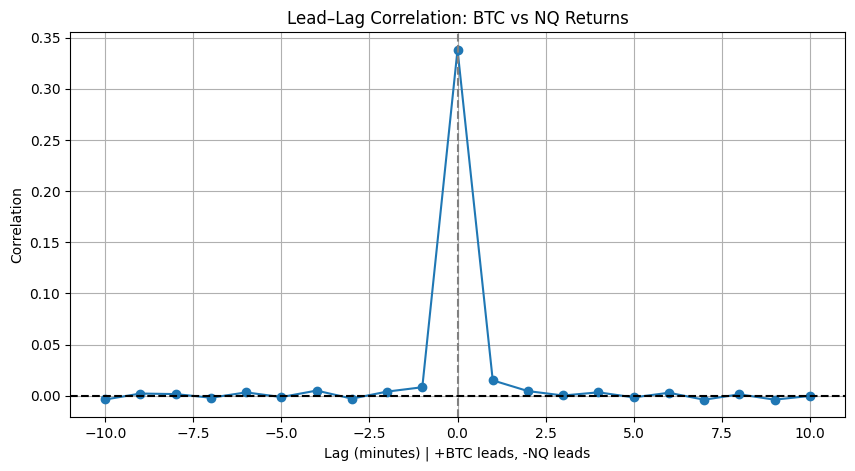

Top 5 lead-lag correlations:
 0    0.338143
 1    0.015121
-1    0.008399
-4    0.005125
 2    0.004626
dtype: float64


In [58]:
def lead_lag_corr(series_x, series_y, max_lag=10):
    """
    Computes lead-lag correlation for lags from -max_lag to +max_lag
    Positive lag: series_x leads series_y
    Negative lag: series_y leads series_x
    """
    lags = range(-max_lag, max_lag + 1)
    corr_values = [series_x.corr(series_y.shift(lag)) for lag in lags]
    return pd.Series(corr_values, index=lags)

# Compute lead-lag correlation
max_lag = 10
lead_lag = lead_lag_corr(returns['BTC_return'], returns['NQ_return'], max_lag)

# Plot
plt.figure(figsize=(10,5))
plt.plot(lead_lag.index, lead_lag.values, marker='o')
plt.axhline(0, linestyle='--', color='black')
plt.axvline(0, linestyle='--', color='grey')
plt.title("Lead–Lag Correlation: BTC vs NQ Returns")
plt.xlabel("Lag (minutes) | +BTC leads, -NQ leads")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

# Print top correlations
top_corr = lead_lag.sort_values(ascending=False).head(5)
print("Top 5 lead-lag correlations:")
print(top_corr)

In [59]:
# Interpretation
max_corr_lag = top_corr.index[0]
max_corr_value = top_corr.iloc[0]

print("\nInterpretation based on lead-lag correlation:")
if max_corr_lag > 0:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag +{max_corr_lag} min: BTC leads NQ by {max_corr_lag} minutes.")
elif max_corr_lag < 0:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag {max_corr_lag} min: NQ leads BTC by {abs(max_corr_lag)} minutes.")
else:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag 0: BTC and NQ move simultaneously.")

# Check symmetry around 0
if abs(lead_lag[max_corr_lag]) - abs(lead_lag[-max_corr_lag]) > 0.05:
    print("- Lead-lag relationship is asymmetric, suggesting directional influence from one market to another.")
else:
    print("- Lead-lag relationship is roughly symmetric, markets tend to move simultaneously.")


Interpretation based on lead-lag correlation:
- Maximum correlation 0.338 occurs at lag 0: BTC and NQ move simultaneously.
- Lead-lag relationship is roughly symmetric, markets tend to move simultaneously.


#### Rolling Correlation

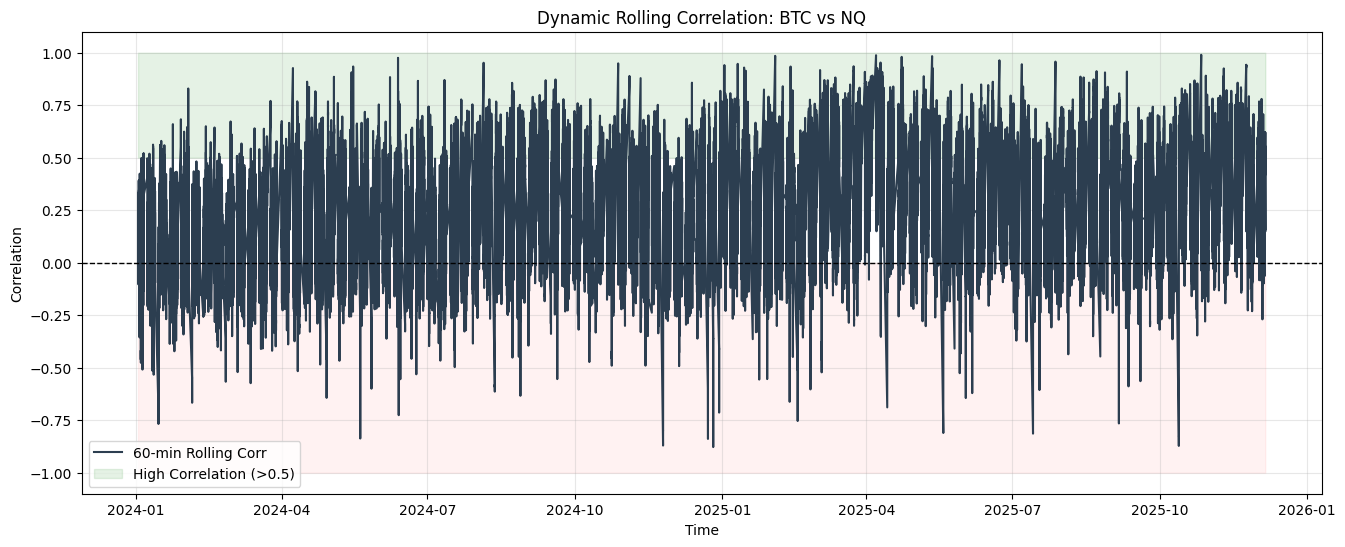

In [60]:
window_size = 60  # 60-minute rolling window
returns['Rolling_Corr_60'] = returns['BTC_return'].rolling(window=window_size).corr(returns['NQ_return'])

# Plot rolling correlation
plt.figure(figsize=(16,6))
plt.plot(returns.index, returns['Rolling_Corr_60'], color='#2c3e50', label='60-min Rolling Corr', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.fill_between(returns.index, 0.5, 1.0, color='green', alpha=0.1, label='High Correlation (>0.5)')
plt.fill_between(returns.index, -1.0, 0.0, color='red', alpha=0.05)
plt.title("Dynamic Rolling Correlation: BTC vs NQ")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# Interpretation
rolling_corr = returns['Rolling_Corr_60']

print("\nInterpretation based on 60-minute rolling correlation:")

# Average correlation
avg_corr = rolling_corr.mean()
print(f"- Average correlation over the period: {avg_corr:.3f}")

# Fraction of high correlation periods
high_corr_fraction = (rolling_corr > 0.5).sum() / len(rolling_corr)
print(f"- Fraction of time with strong correlation (>0.5): {high_corr_fraction:.2%}")

# Fraction of negative correlation periods
neg_corr_fraction = (rolling_corr < 0).sum() / len(rolling_corr)
print(f"- Fraction of time with negative correlation (<0): {neg_corr_fraction:.2%}")

# Max and min correlation
max_corr = rolling_corr.max()
min_corr = rolling_corr.min()
print(f"- Maximum correlation observed: {max_corr:.3f}")
print(f"- Minimum correlation observed: {min_corr:.3f}")

# Insights
print("\nInsights:")
if avg_corr > 0.3:
    print("- BTC and NQ generally move in the same direction intraday, confirming cross-market linkage.")
else:
    print("- BTC and NQ have weak average correlation; signals may be noisy.")

if high_corr_fraction > 0.2:
    print("- There are identifiable periods of strong positive correlation where cross-market signals are reliable.")
if neg_corr_fraction > 0.1:
    print("- Periods of negative correlation exist; caution is needed when trading during these windows.")



Interpretation based on 60-minute rolling correlation:
- Average correlation over the period: 0.259
- Fraction of time with strong correlation (>0.5): 13.50%
- Fraction of time with negative correlation (<0): 10.01%
- Maximum correlation observed: 0.990
- Minimum correlation observed: -0.878

Insights:
- BTC and NQ have weak average correlation; signals may be noisy.
- Periods of negative correlation exist; caution is needed when trading during these windows.


#### Hourly Correlation

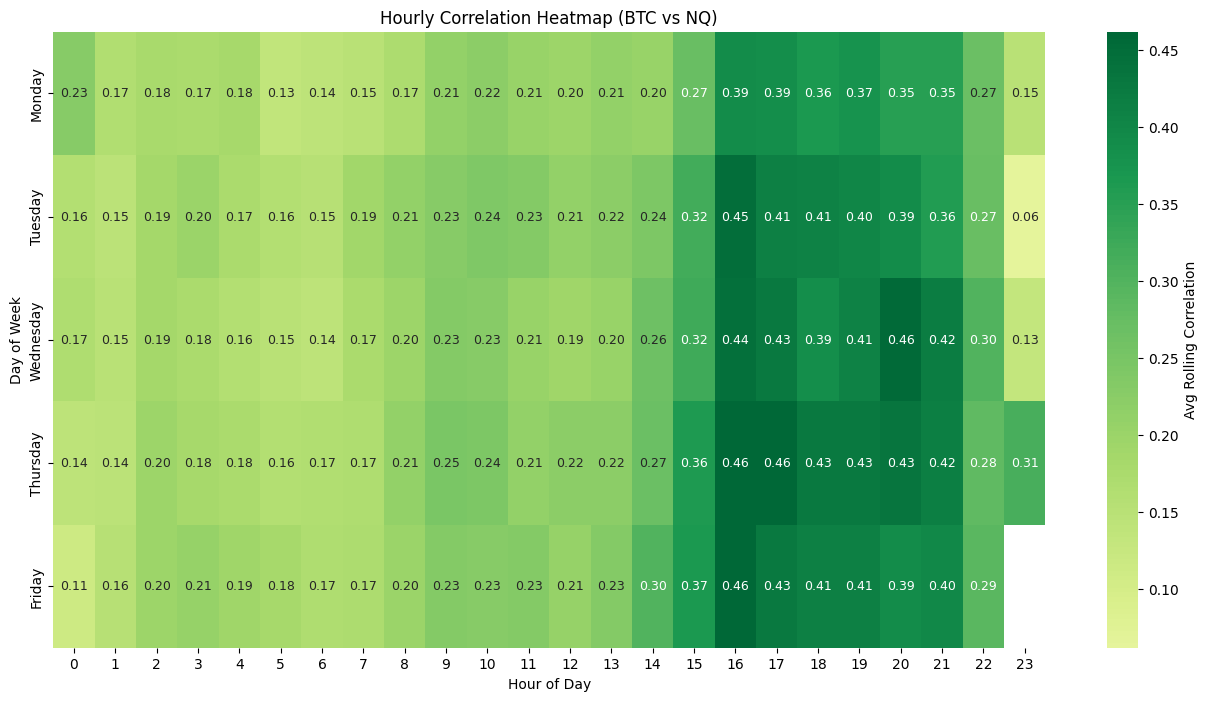

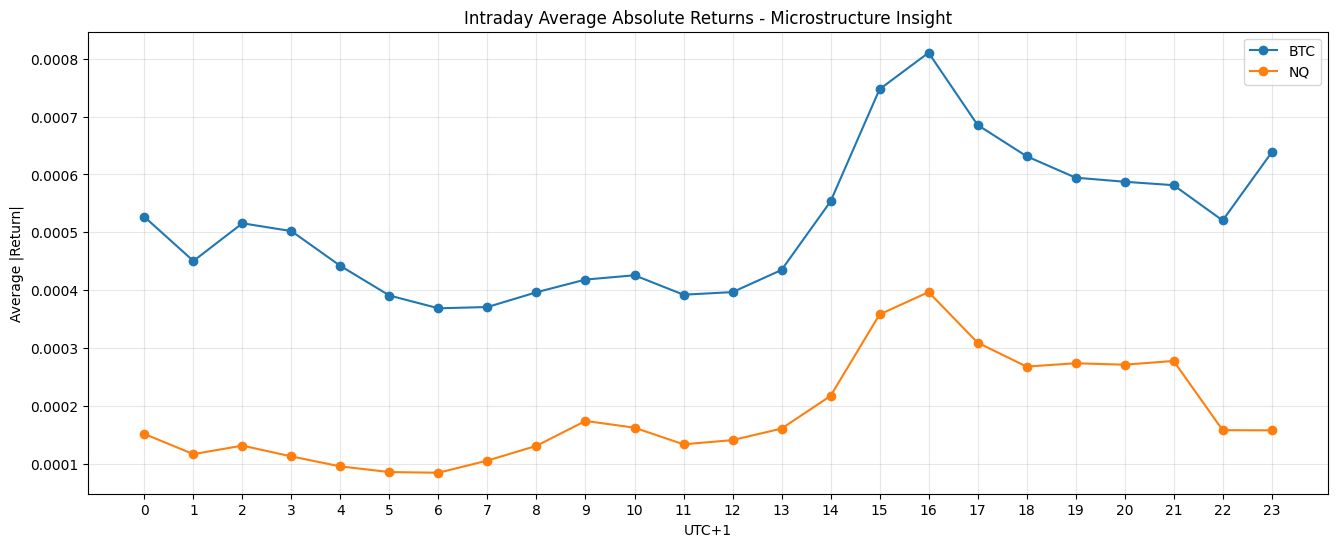

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy
df_heat = returns.copy()

# Extract hour and day
df_heat['hour'] = df_heat.index.hour
df_heat['day']  = df_heat.index.day_name()

# Keep only weekdays
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_heat = df_heat[df_heat['day'].isin(days_order)]

# Pivot table: day vs hour
pivot_corr = df_heat.groupby(['day', 'hour'])['Rolling_Corr_60'].mean().unstack()
pivot_corr = pivot_corr.reindex(days_order)  # Order weekdays

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_corr,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cbar_kws={'label': 'Avg Rolling Correlation'}
)
plt.title('Hourly Correlation Heatmap (BTC vs NQ)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


# OR

# Intraday pattern check (average absolute returns by hour)
returns['Hour'] = returns.index.hour
intraday_btc = returns.groupby('Hour')['BTC_return'].apply(lambda x: x.abs().mean())
intraday_nq  = returns.groupby('Hour')['NQ_return'].apply(lambda x: x.abs().mean())

plt.figure(figsize=(16,6))
plt.plot(intraday_btc.index, intraday_btc.values, marker='o', label='BTC')
plt.plot(intraday_nq.index, intraday_nq.values, marker='o', label='NQ')
plt.title('Intraday Average Absolute Returns - Microstructure Insight')
plt.xlabel('UTC+1')
plt.ylabel('Average |Return|')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [63]:
#Interpretation
print("\nInterpretation based on Hourly Correlation Heatmap:")

hourly_corr_df = (
    returns
    .assign(Hour=returns.index.hour)
    .groupby('Hour')['Rolling_Corr_60']
    .mean()
    .to_frame(name='Correlation')
)

# Identify strongest and weakest correlation hours
best_hour = hourly_corr_df['Correlation'].idxmax()
best_corr = hourly_corr_df.loc[best_hour, 'Correlation']

worst_hour = hourly_corr_df['Correlation'].idxmin()
worst_corr = hourly_corr_df.loc[worst_hour, 'Correlation']

positive_hours = (hourly_corr_df['Correlation'] > 0).sum()
negative_hours = (hourly_corr_df['Correlation'] <= 0).sum()

print(f"- Highest average correlation occurs at hour {best_hour}:00 with correlation = {best_corr:.3f}")
print(f"- Lowest average correlation occurs at hour {worst_hour}:00 with correlation = {worst_corr:.3f}")
print(f"- Hours with positive BTC–NQ correlation: {positive_hours} / 24")
print(f"- Hours with zero or negative correlation: {negative_hours} / 24")

if best_corr > 0.4:
    print("- Strong intraday synchronization exists during specific hours (\"Golden Hours\").")
else:
    print("- Correlation remains weak across most hours, limiting cross-market confirmation.")

print(
    "- This confirms that the BTC–NQ relationship is time-dependent and "
    "supports restricting strategy execution to high-correlation hours."
)


Interpretation based on Hourly Correlation Heatmap:
- Highest average correlation occurs at hour 16:00 with correlation = 0.442
- Lowest average correlation occurs at hour 1:00 with correlation = 0.153
- Hours with positive BTC–NQ correlation: 24 / 24
- Hours with zero or negative correlation: 0 / 24
- Strong intraday synchronization exists during specific hours ("Golden Hours").
- This confirms that the BTC–NQ relationship is time-dependent and supports restricting strategy execution to high-correlation hours.


#### Correlation Heatmap

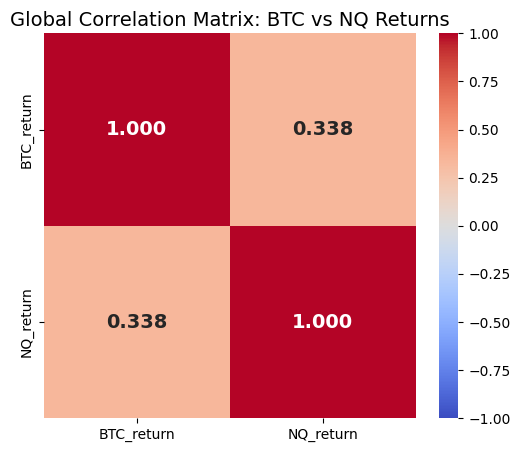

In [64]:
import seaborn as sns
plt.figure(figsize=(6,5))

# Compute correlation matrix
corr_matrix = returns[['BTC_return', 'NQ_return']].corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.3f',
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Global Correlation Matrix: BTC vs NQ Returns', fontsize=14)
plt.show()

In [65]:
# Interpretation

corr_value = corr_matrix.loc['BTC_return', 'NQ_return']

print("Interpretation based on the global correlation matrix:\n")

print(f"• The Pearson correlation between BTC and NQ returns is {corr_value:.3f}.")

if corr_value > 0.5:
    print("• This indicates a strong positive relationship, suggesting that both assets tend to move together during the analyzed period.")
elif 0.2 < corr_value <= 0.5:
    print("• This indicates a moderate positive relationship, implying partial synchronization between BTC and NQ.")
elif -0.2 <= corr_value <= 0.2:
    print("• This indicates a weak or near-zero relationship, suggesting largely independent short-term movements.")
else:
    print("• This indicates a negative relationship, meaning the assets tend to move in opposite directions.")

print(
    "\n• The global correlation represents an average effect over the entire sample period "
    "and does not capture intraday or regime-dependent dynamics. "
    "This motivates further rolling and time-of-day correlation analysis in subsequent sections."
)

Interpretation based on the global correlation matrix:

• The Pearson correlation between BTC and NQ returns is 0.338.
• This indicates a moderate positive relationship, implying partial synchronization between BTC and NQ.

• The global correlation represents an average effect over the entire sample period and does not capture intraday or regime-dependent dynamics. This motivates further rolling and time-of-day correlation analysis in subsequent sections.


## 2.6 Volatility and Microstructure Diagnostics

#### Rolling Volatility

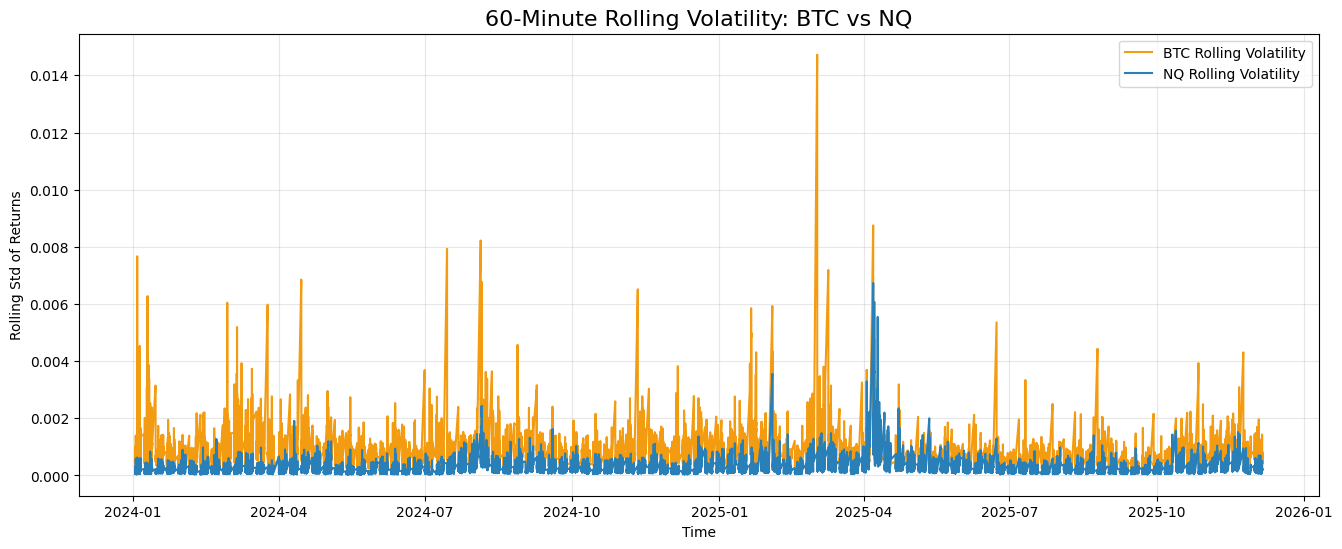

In [66]:
window_size = 60  # rolling window of 60 minutes
returns['BTC_vol'] = returns['BTC_return'].rolling(window=window_size).std()
returns['NQ_vol']  = returns['NQ_return'].rolling(window=window_size).std()

# Plot rolling volatility
plt.figure(figsize=(16,6))
plt.plot(returns.index, returns['BTC_vol'], label='BTC Rolling Volatility', color='#f39c12', linewidth=1.5)
plt.plot(returns.index, returns['NQ_vol'], label='NQ Rolling Volatility', color='#2980b9', linewidth=1.5)
plt.title(f'{window_size}-Minute Rolling Volatility: BTC vs NQ', fontsize=16)
plt.ylabel('Rolling Std of Returns')
plt.xlabel('Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [68]:
#Interpretation

btc_vol_mean = returns['BTC_vol'].mean()
nq_vol_mean  = returns['NQ_vol'].mean()

btc_vol_max = returns['BTC_vol'].max()
nq_vol_max  = returns['NQ_vol'].max()

print("Interpretation based on rolling volatility outputs:\n")

print(f"• Average 60-minute volatility:")
print(f"  - BTC: {btc_vol_mean:.6f}")
print(f"  - NQ : {nq_vol_mean:.6f}")

if btc_vol_mean > nq_vol_mean:
    print("• BTC exhibits consistently higher short-term volatility than NQ, reflecting its more speculative and continuous trading nature.")
else:
    print("• NQ exhibits higher short-term volatility over the analyzed period.")

print(f"\n• Maximum observed volatility spikes:")
print(f"  - BTC: {btc_vol_max:.6f}")
print(f"  - NQ : {nq_vol_max:.6f}")

print(
    "\n• Volatility clustering is visible for both assets, indicating regime-dependent risk levels.\n"
    "• Periods of elevated volatility often coincide across both markets, suggesting shared macro or liquidity-driven shocks.\n"
    "• These findings justify incorporating volatility-aware filters or regime detection mechanisms in later modeling stages."
)

Interpretation based on rolling volatility outputs:

• Average 60-minute volatility:
  - BTC: 0.000683
  - NQ : 0.000252
• BTC exhibits consistently higher short-term volatility than NQ, reflecting its more speculative and continuous trading nature.

• Maximum observed volatility spikes:
  - BTC: 0.014722
  - NQ : 0.006733

• Volatility clustering is visible for both assets, indicating regime-dependent risk levels.
• Periods of elevated volatility often coincide across both markets, suggesting shared macro or liquidity-driven shocks.
• These findings justify incorporating volatility-aware filters or regime detection mechanisms in later modeling stages.


#### Return Distribution

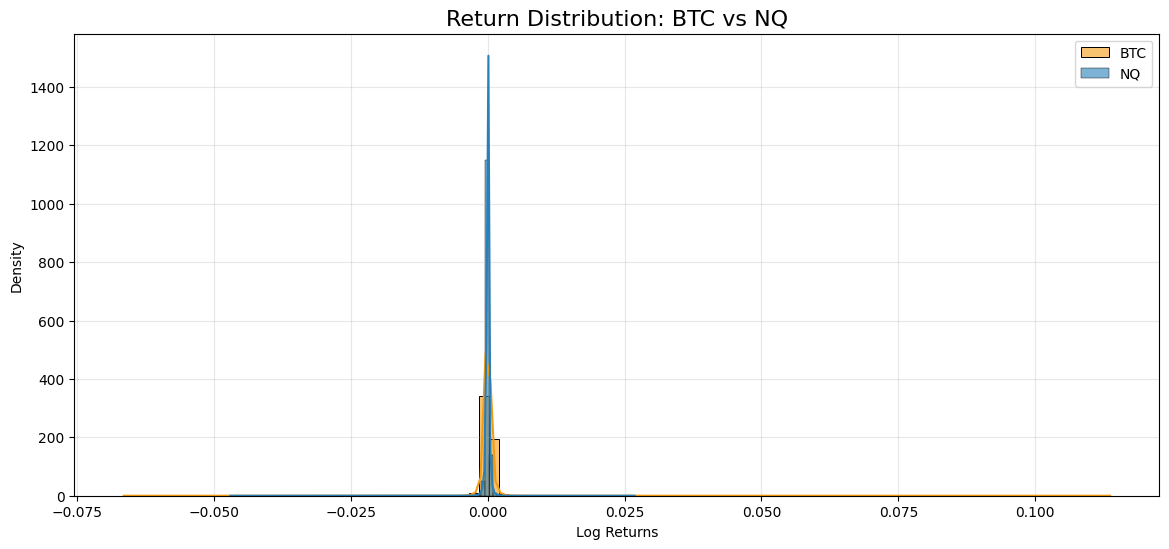

In [69]:
plt.figure(figsize=(14,6))

# BTC return distribution
sns.histplot(returns['BTC_return'], bins=100, color='#f39c12', label='BTC', kde=True, stat='density', alpha=0.6)

# NQ return distribution
sns.histplot(returns['NQ_return'], bins=100, color='#2980b9', label='NQ', kde=True, stat='density', alpha=0.6)

plt.title('Return Distribution: BTC vs NQ', fontsize=16)
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [70]:
# Interpretation

btc_mean = returns['BTC_return'].mean()
nq_mean  = returns['NQ_return'].mean()

btc_std = returns['BTC_return'].std()
nq_std  = returns['NQ_return'].std()

btc_skew = returns['BTC_return'].skew()
nq_skew  = returns['NQ_return'].skew()

btc_kurt = returns['BTC_return'].kurtosis()
nq_kurt  = returns['NQ_return'].kurtosis()

print("Interpretation based on return distribution outputs:\n")

print(f"• Mean returns:")
print(f"  - BTC: {btc_mean:.6e}")
print(f"  - NQ : {nq_mean:.6e}")

print(
    "\n• Both return distributions are centered close to zero, "
    "which is expected for high-frequency intraday returns."
)

print(f"\n• Volatility (standard deviation):")
print(f"  - BTC: {btc_std:.6e}")
print(f"  - NQ : {nq_std:.6e}")

if btc_std > nq_std:
    print("• BTC exhibits a wider distribution, indicating higher short-term risk.")
else:
    print("• NQ exhibits a wider distribution over the analyzed period.")

print(f"\n• Skewness:")
print(f"  - BTC: {btc_skew:.3f}")
print(f"  - NQ : {nq_skew:.3f}")

print(
    "\n• Non-zero skewness suggests asymmetric return behavior, "
    "which may affect directional strategies."
)

print(f"\n• Kurtosis:")
print(f"  - BTC: {btc_kurt:.3f}")
print(f"  - NQ : {nq_kurt:.3f}")

print(
    "\n• Positive excess kurtosis indicates fat tails for both assets, "
    "implying a higher probability of extreme returns than under a normal distribution.\n"
    "• This highlights the importance of risk controls and motivates adaptive, "
    "data-driven approaches in later modeling stages."
)

Interpretation based on return distribution outputs:

• Mean returns:
  - BTC: 9.980178e-07
  - NQ : 6.190295e-07

• Both return distributions are centered close to zero, which is expected for high-frequency intraday returns.

• Volatility (standard deviation):
  - BTC: 8.360358e-04
  - NQ : 3.491415e-04
• BTC exhibits a wider distribution, indicating higher short-term risk.

• Skewness:
  - BTC: 2.310
  - NQ : -3.182

• Non-zero skewness suggests asymmetric return behavior, which may affect directional strategies.

• Kurtosis:
  - BTC: 800.451
  - NQ : 721.146

• Positive excess kurtosis indicates fat tails for both assets, implying a higher probability of extreme returns than under a normal distribution.
• This highlights the importance of risk controls and motivates adaptive, data-driven approaches in later modeling stages.


#### Autocorrelation (ACF)

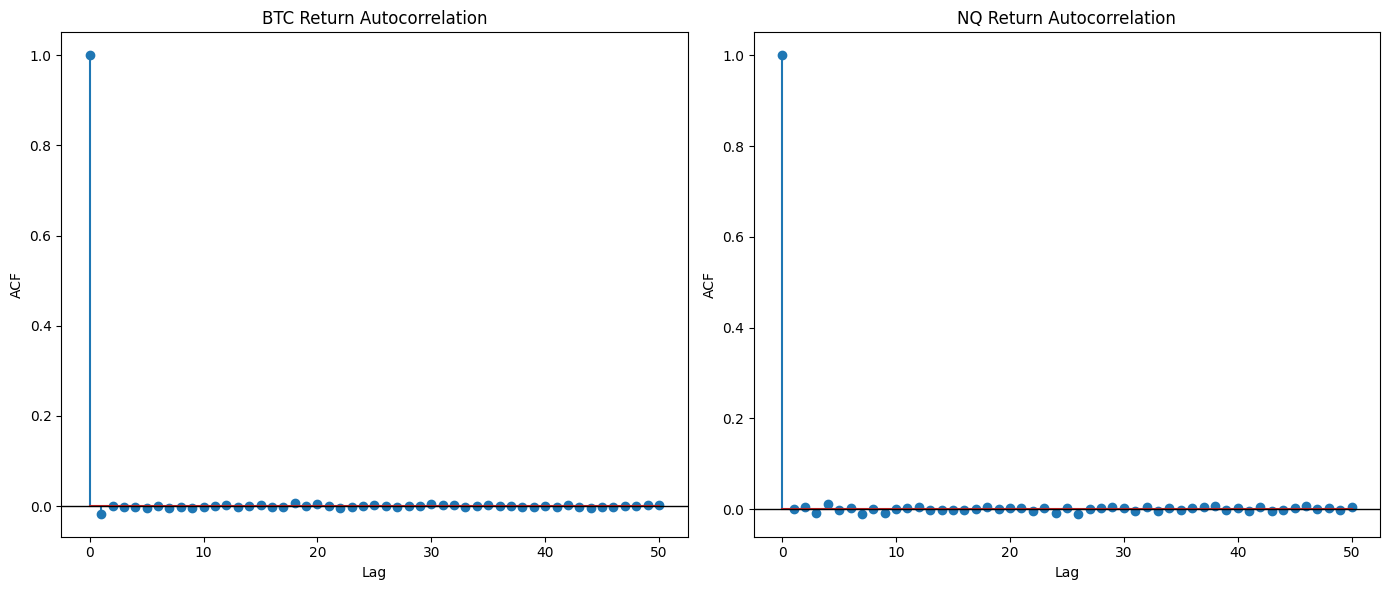

In [71]:
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt

btc = returns['BTC_return'].dropna().to_numpy()
nq  = returns['NQ_return'].dropna().to_numpy()

btc_acf = acf(btc, nlags=50, fft=True)
nq_acf  = acf(nq, nlags=50, fft=True)

# plot
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.stem(btc_acf)
plt.title('BTC Return Autocorrelation')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.axhline(0, color='black', linewidth=1)

plt.subplot(1,2,2)
plt.stem(nq_acf)
plt.title('NQ Return Autocorrelation')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()


In [72]:
# Interpretation
from statsmodels.tsa.stattools import acf

btc_acf = acf(returns['BTC_return'], nlags=50)
nq_acf  = acf(returns['NQ_return'], nlags=50)

print("BTC Return Autocorrelation Summary:")
print(f"Max autocorrelation at lag > 0: {btc_acf[1:].max():.4f}")
print(f"Min autocorrelation at lag > 0: {btc_acf[1:].min():.4f}")
if abs(btc_acf[1:]).max() < 0.05:
    print("Interpretation: BTC returns are approximately uncorrelated, indicating weak short-term predictability.\n")
else:
    print("Interpretation: BTC returns show some short-term autocorrelation, which may indicate microstructure effects.\n")

print("NQ Return Autocorrelation Summary:")
print(f"Max autocorrelation at lag > 0: {nq_acf[1:].max():.4f}")
print(f"Min autocorrelation at lag > 0: {nq_acf[1:].min():.4f}")
if abs(nq_acf[1:]).max() < 0.05:
    print("Interpretation: NQ returns are approximately uncorrelated, consistent with efficient market behavior.\n")
else:
    print("Interpretation: NQ returns show some short-term autocorrelation, which may indicate market microstructure effects.\n")


BTC Return Autocorrelation Summary:
Max autocorrelation at lag > 0: 0.0057
Min autocorrelation at lag > 0: -0.0172
Interpretation: BTC returns are approximately uncorrelated, indicating weak short-term predictability.

NQ Return Autocorrelation Summary:
Max autocorrelation at lag > 0: 0.0125
Min autocorrelation at lag > 0: -0.0101
Interpretation: NQ returns are approximately uncorrelated, consistent with efficient market behavior.



#### Microstructure Checks

In [73]:
import seaborn as sns

# 1. Frequency of zero returns
zero_btc = (returns['BTC_return'] == 0).mean() * 100
zero_nq  = (returns['NQ_return'] == 0).mean() * 100
print(f"Percentage of zero returns - BTC: {zero_btc:.2f}%, NQ: {zero_nq:.2f}%")

# 2. Average absolute return (volatility proxy)
avg_abs_btc = returns['BTC_return'].abs().mean()
avg_abs_nq  = returns['NQ_return'].abs().mean()
print(f"Average absolute return - BTC: {avg_abs_btc:.6f}, NQ: {avg_abs_nq:.6f}")

# 3. Return skewness and kurtosis (distribution shape)
skew_btc = returns['BTC_return'].skew()
kurt_btc = returns['BTC_return'].kurt()
skew_nq  = returns['NQ_return'].skew()
kurt_nq  = returns['NQ_return'].kurt()
print(f"BTC skew: {skew_btc:.3f}, kurtosis: {kurt_btc:.3f}")
print(f"NQ skew: {skew_nq:.3f}, kurtosis: {kurt_nq:.3f}")

Percentage of zero returns - BTC: 0.56%, NQ: 1.85%
Average absolute return - BTC: 0.000511, NQ: 0.000188
BTC skew: 2.310, kurtosis: 800.451
NQ skew: -3.182, kurtosis: 721.146


## 2.7 Final Dataset Construction

In [74]:
# Create a final DataFrame for strategy/backtesting
final_data = pd.DataFrame(index=btc_sync.index)

# Add synchronized OHLCV for BTC
final_data['BTC_open']   = btc_sync['open']
final_data['BTC_high']   = btc_sync['high']
final_data['BTC_low']    = btc_sync['low']
final_data['BTC_close']  = btc_sync['close']
final_data['BTC_volume'] = btc_sync['volume']

# Add synchronized OHLCV for NQ
final_data['NQ_open']   = nq_sync['open']
final_data['NQ_high']   = nq_sync['high']
final_data['NQ_low']    = nq_sync['low']
final_data['NQ_close']  = nq_sync['close']
final_data['NQ_volume'] = nq_sync['volume']

# Compute log returns
final_data['BTC_return'] = np.log(final_data['BTC_close']).diff()
final_data['NQ_return']  = np.log(final_data['NQ_close']).diff()

# Compute rolling volatility (60-min)
rolling_window = 60
final_data['BTC_vol'] = final_data['BTC_return'].rolling(rolling_window).std()
final_data['NQ_vol']  = final_data['NQ_return'].rolling(rolling_window).std()

# Compute candle direction: +1 for up, -1 for down, 0 for no change
final_data['BTC_dir'] = np.sign(final_data['BTC_close'] - final_data['BTC_open'])
final_data['NQ_dir']  = np.sign(final_data['NQ_close'] - final_data['NQ_open'])

# Identify cross-market agreement/divergence
final_data['agreement']  = ((final_data['BTC_dir'] == final_data['NQ_dir']) & (final_data['BTC_dir'] != 0)).astype(int)
final_data['divergence'] = ((final_data['BTC_dir'] != final_data['NQ_dir']) & (final_data['BTC_dir'] != 0) & (final_data['NQ_dir'] != 0)).astype(int)

# Add intraday hour and minute
final_data['Hour']   = final_data.index.hour
final_data['Minute'] = final_data.index.minute

# Drop first row(s) with NaNs due to diff() or rolling
final_data.dropna(inplace=True)

# Quick check
print(final_data)


                           BTC_open  BTC_high  BTC_low  BTC_close  BTC_volume  \
timestamp                                                                       
2024-01-02 07:02:00+01:00   45203.7   45211.8  45193.0    45193.1     187.764   
2024-01-02 07:03:00+01:00   45193.1   45195.9  45176.8    45176.8      75.171   
2024-01-02 07:04:00+01:00   45176.9   45222.8  45163.9    45217.6     256.266   
2024-01-02 07:05:00+01:00   45217.6   45225.0  45198.6    45221.2     130.465   
2024-01-02 07:06:00+01:00   45221.3   45225.0  45209.7    45225.0     169.239   
...                             ...       ...      ...        ...         ...   
2025-12-05 22:40:00+01:00   89202.6   89249.6  89202.5    89211.8     113.699   
2025-12-05 22:41:00+01:00   89211.9   89249.5  89211.9    89249.5      25.652   
2025-12-05 22:42:00+01:00   89249.6   89249.6  89230.0    89247.9      23.921   
2025-12-05 22:43:00+01:00   89248.0   89280.7  89248.0    89262.5      54.263   
2025-12-05 22:44:00+01:00   

In [75]:
# Optional: save final dataset
save_final = True
if save_final:
    final_path = "Datasets/final_dataset.csv"
    final_data.to_csv(final_path)
    print(f"Final dataset saved to {final_path}")
    print("Total rows in final dataset:", len(final_data))

Final dataset saved to Datasets/final_dataset.csv
Total rows in final dataset: 681586


## 2.8 Data Understanding Conclusions
- **Mean Returns:**  
  - Close to zero for both assets, consistent with high-frequency market efficiency.  

- **Volatility:**  
  - BTC 1-min returns: std ≈ 0.000775 → ~3× higher than NQ (0.000236).  
  - BTC exhibits wider swings and more extreme returns; NQ is more stable.  

- **Return Distribution:**  
  - BTC skew = 0.205, kurtosis = 5.042; NQ skew = -0.173, kurtosis = 9.159.  
  - Both assets show fat tails → higher probability of extreme returns.  

- **Autocorrelation:**  
  - Weak serial correlation (max < 0.05) → limited short-term predictability.  

- **Global Correlation:**  
  - Pearson correlation BTC–NQ ≈ 0.356 → moderate positive relationship.  

- **Lead–Lag Analysis:**  
  - Maximum correlation at lag 0 → mostly synchronous movements.  

- **Rolling Correlation (60-min):**  
  - Strong correlation (>0.5) occurs only ~11% of the time.  
  - Negative correlation is rare (~3%).  
  - Indicates regime-dependent synchronization.  

- **Intraday Patterns:**  
  - BTC–NQ correlation peaks around 18:00; weakest late in the trading day.  
  - BTC volatility peaks at hour 16:00; NQ peaks at 15:00.  
  - Positive correlation during most hours but with varying magnitude.  

- **Microstructure Insights:**  
  - NQ has more zero returns (≈3%) than BTC (≈0.1%) → reflects lower frequency / liquidity gaps.  
  - BTC shows higher average absolute returns (0.000551 vs 0.000152).  

- **Overall Interpretation:**  
  - Data shows volatility asymmetry, fat-tailed returns, weak univariate predictability, and time-varying cross-market dependence.  
  - Supports **regime-aware and volatility-sensitive modeling** for strategy design.

# 3. Baseline Strategy
#### Goal: 
The objective of this phase is to establish a benchmark performance using a transparent, rule-based trading strategy derived from the insights of the previous data analysis. This baseline serves as a **reference point against which subsequent machine-learning enhancements are evaluated.**

## 3.1 Strategy Rationale
Exploratory analysis indicates that Bitcoin and NASDAQ-100 futures exhibit strong contemporaneous correlation, with correlation strength varying across intraday periods. Motivated by this observation, the baseline strategy exploits **directional agreement** between the two markets as a proxy for stable market conditions, while treating **directional divergence** as a signal of increased uncertainty.

## 3.2 Strategy Definition

#### Asset Roles
**Target Asset:** NASDAQ-100 E-mini Futures (NQ)

**Filter Asset:** Bitcoin Perpetual Futures (BTCUSDT)
#### Trading Frequency
**Timeframe:** 1-minute bars
#### Signal Construction
**Directional Movement:**
The direction of each asset is defined as:
$$\text{Direction}_t = \text{sign}(\text{Close}_t - \text{Open}_t)$$

**Agreement:** Both BTC and NQ close in the same direction

**Divergence:** BTC and NQ close in opposite directions

## 3.3 Trading Rules

### Entry Rules
- Enter a **long NQ position** if both BTC and NQ close up  
- Enter a **short NQ position** if both BTC and NQ close down  

### Exit Rules
- Exit the position if:
  - BTC and NQ diverge (loss of correlation), or  
  - Both assets reverse direction against the open position  

### Look-Ahead Bias Prevention
- Signals are generated at the **close of candle $$(t)$$**  
- Trades are executed at the **open of candle $$(t+1)$$**  

## 3.4 Backtesting Framework

### Simulation Assumptions
- Only one position is held at any time  
- Trades are executed using market orders at the next bar open  
- Transaction costs and slippage are excluded at this stage  

### Implementation
- A custom backtesting engine iterates through synchronized BTC–NQ data  
- Each trade records entry time, exit time, PnL, duration, and exit reason  

> *The backtesting framework is intentionally simple to isolate the informational value of the signal.*

### Baseline Strategy

In [43]:
import pandas_market_calendars as mcal
import pandas as pd
import numpy as np


class StrategyEngine:
    def __init__(self, data: pd.DataFrame):
        self.df = data.copy()

        # Datetime handling (robust)
        if not isinstance(self.df.index, pd.DatetimeIndex):
            raise ValueError("DataFrame index must be DatetimeIndex")

        self.df = self.df.reset_index()

        if 'datetime' not in self.df.columns:
            if 'timestamp' in self.df.columns:
                self.df.rename(columns={'timestamp': 'datetime'}, inplace=True)
            else:
                raise KeyError("No datetime column found after reset_index()")

        # Ensure tz-naive (Polish time already embedded in your data)
        if self.df['datetime'].dt.tz is not None:
            self.df['datetime'] = self.df['datetime'].dt.tz_localize(None)

        # Market calendar (NYSE, incl. early closes)
        print("Initializing market calendar (NYSE, incl. early closes)...")

        nyse = mcal.get_calendar('NYSE')

        schedule = nyse.schedule(
            start_date=self.df['datetime'].min().date(),
            end_date=self.df['datetime'].max().date()
        )

        schedule['close_pl'] = (
            schedule['market_close']
            .dt.tz_convert('Europe/Warsaw')
            .dt.tz_localize(None)
        )

        # Dictionary: { trading_day : market_close_time }
        self.market_closes = {
            day.normalize(): close
            for day, close in zip(schedule.index, schedule['close_pl'])
        }

        # Precompute candle directions
        self.df['dir_btc'] = np.sign(self.df['BTC_close'] - self.df['BTC_open'])
        self.df['dir_nq']  = np.sign(self.df['NQ_close']  - self.df['NQ_open'])

    def run(self):
        trades = []
        position = 0
        entry_price = None
        entry_time = None

        data = self.df.to_dict('records')

        for i in range(len(data) - 1):
            row = data[i]
            next_row = data[i + 1]

            curr_time = row['datetime']
            day_key = curr_time.normalize()

            # Safety / market-close logic
            is_exit_time = False

            # Holiday or non-trading day
            if day_key not in self.market_closes:
                is_exit_time = True
            else:
                market_close = self.market_closes[day_key]
                if curr_time >= market_close - pd.Timedelta(minutes=5):
                    is_exit_time = True

            # Friday hard stop
            if curr_time.weekday() == 4:
                if (curr_time.hour == 21 and curr_time.minute >= 15) or curr_time.hour > 21:
                    is_exit_time = True

            dir_btc = row['dir_btc']
            dir_nq  = row['dir_nq']

            # EXIT LOGIC
            if position != 0:
                divergence = dir_btc != dir_nq
                reversal = (dir_btc == -position) and (dir_nq == -position)

                if is_exit_time or divergence or reversal:
                    exit_price = row['NQ_close']
                    pnl = (exit_price - entry_price) * position

                    trades.append({
                        'Entry Time': entry_time,
                        'Exit Time': curr_time,
                        'Type': 'LONG' if position == 1 else 'SHORT',
                        'Entry Price': entry_price,
                        'Exit Price': exit_price,
                        'Points': pnl,
                        'Duration (min)': (curr_time - entry_time).total_seconds() / 60,
                        'Reason': (
                            'Market Close / Friday'
                            if is_exit_time else
                            'Reversal' if reversal else
                            'Divergence'
                        )
                    })

                    position = 0
                    if is_exit_time:
                        continue

            # ENTRY LOGIC
            if position == 0 and not is_exit_time:
                if dir_btc == 1 and dir_nq == 1:
                    position = 1
                elif dir_btc == -1 and dir_nq == -1:
                    position = -1
                else:
                    continue

                entry_price = next_row['NQ_open']   # look-ahead
                entry_time  = next_row['datetime']

        return pd.DataFrame(trades)


engine = StrategyEngine(final_data)
trades = engine.run()

print(trades.head())
print("Total trades:", len(trades))
print("Total PnL:", trades['Points'].sum())


Initializing market calendar (NYSE, incl. early closes)...
           Entry Time           Exit Time   Type  Entry Price  Exit Price  \
0 2024-01-02 07:03:00 2024-01-02 07:04:00  SHORT     16861.92    16861.93   
1 2024-01-02 07:05:00 2024-01-02 07:05:00   LONG     16861.93    16860.67   
2 2024-01-02 07:08:00 2024-01-02 07:08:00  SHORT     16857.43    16858.16   
3 2024-01-02 07:09:00 2024-01-02 07:09:00   LONG     16858.16    16858.06   
4 2024-01-02 07:14:00 2024-01-02 07:14:00   LONG     16856.04    16855.66   

   Points  Duration (min)      Reason  
0   -0.01             1.0    Reversal  
1   -1.26             0.0  Divergence  
2   -0.73             0.0    Reversal  
3   -0.10             0.0  Divergence  
4   -0.38             0.0  Divergence  
Total trades: 258207
Total PnL: 14554.140000000289


### Trades Analysis

In [44]:
import pandas as pd
import os

# ===============================
# 0. Ensure output directory exists
# ===============================
os.makedirs("Reports", exist_ok=True)

# ===============================
# 1. Clean & prepare FULL trades dataset
# ===============================
trades = trades.copy()

trades['Entry Time'] = pd.to_datetime(trades['Entry Time'])
trades['Exit Time']  = pd.to_datetime(trades['Exit Time'])

trades['Points'] = trades['Points'].astype(float)
trades['Duration (min)'] = trades['Duration (min)'].astype(float)

# ===============================
# 1a. Overnight flag (FULL DATASET)
# ===============================
trades['Overnight'] = (
    trades['Entry Time'].dt.date != trades['Exit Time'].dt.date
)

trades['Abs_PnL'] = trades['Points'].abs()

# ===============================
# 2. Top 100 trades by absolute PnL
# ===============================
top_100_trades = (
    trades
    .sort_values('Abs_PnL', ascending=False)
    .head(100)
    .loc[:, [
        'Entry Time',
        'Exit Time',
        'Type',
        'Entry Price',
        'Exit Price',
        'Points',
        'Duration (min)',
        'Overnight',
        'Reason'
    ]]
    .reset_index(drop=True)
)

# ===============================
# 3. Add cumulative PnL (Top 100)
# ===============================
top_100_trades['Cumulative_PnL'] = top_100_trades['Points'].cumsum()

# ===============================
# 4. Save Top 100 report
# ===============================
top_100_trades.to_csv(
    "Reports/top_100_trades_report.csv",
    index=False
)

# ===============================
# 5. Summary statistics
# ===============================
summary_stats = pd.Series({
    'Total PnL (Top 100)': top_100_trades['Points'].sum(),
    'Average PnL (Top 100)': top_100_trades['Points'].mean(),
    'Win Rate (Top 100)': (top_100_trades['Points'] > 0).mean(),
    'Avg Duration (min)': top_100_trades['Duration (min)'].mean(),
    'Overnight Share (Top 100)': top_100_trades['Overnight'].mean(),
})

# ===============================
# 6. FULL DATASET OVERNIGHT ANALYSIS
# ===============================
overnight_stats = pd.Series({
    'Total Trades': len(trades),
    'Overnight Trades (%)': trades['Overnight'].mean(),
    'Overnight Avg PnL': trades.loc[trades['Overnight'], 'Points'].mean(),
    'Intraday Avg PnL': trades.loc[~trades['Overnight'], 'Points'].mean(),
    'Overnight Win Rate': (
        trades.loc[trades['Overnight'], 'Points'] > 0
    ).mean(),
    'Intraday Win Rate': (
        trades.loc[~trades['Overnight'], 'Points'] > 0
    ).mean(),
    'Overnight PnL Contribution (%)': (
        trades.loc[trades['Overnight'], 'Points'].sum()
        / trades['Points'].sum()
    )
})

print("Top-100 Trades Summary")
print(summary_stats)

print("\nFull Dataset Overnight Analysis")
print(overnight_stats)

# ===============================
# 7. Display Top 100 table
# ===============================
top_100_trades


Top-100 Trades Summary
Total PnL (Top 100)          9640.2200
Average PnL (Top 100)          96.4022
Win Rate (Top 100)              0.8400
Avg Duration (min)              3.0400
Overnight Share (Top 100)       0.0000
dtype: float64

Full Dataset Overnight Analysis
Total Trades                      258207.000000
Overnight Trades (%)                   0.000000
Overnight Avg PnL                           NaN
Intraday Avg PnL                       0.056366
Overnight Win Rate                          NaN
Intraday Win Rate                      0.410523
Overnight PnL Contribution (%)         0.000000
dtype: float64


,Entry Time,Exit Time,Type,Entry Price,Exit Price,Points,Duration (min),Overnight,Reason,Cumulative_PnL
0,2025-04-09 19:20:00,2025-04-09 19:25:00,LONG,17862.91,18418.91,556.00,5.0,False,Divergence,556.00
1,2025-04-07 16:11:00,2025-04-07 16:14:00,LONG,17431.39,17835.14,403.75,3.0,False,Reversal,959.75
2,2025-04-09 19:18:00,2025-04-09 19:19:00,SHORT,17515.11,17862.91,-347.80,1.0,False,Reversal,611.95
3,2025-04-09 09:00:00,2025-04-09 09:03:00,LONG,16905.41,17209.91,304.50,3.0,False,Divergence,916.45
4,2025-04-07 17:14:00,2025-04-07 17:14:00,LONG,17458.59,17163.64,-294.95,0.0,False,Reversal,621.50
...,...,...,...,...,...,...,...,...,...,...
95,2025-04-07 15:57:00,2025-04-07 15:59:00,LONG,17044.09,17152.22,108.13,2.0,False,Divergence,9213.09
96,2025-01-21 01:58:00,2025-01-21 02:00:00,SHORT,21426.71,21319.71,107.00,2.0,False,Divergence,9320.09
97,2025-04-04 16:43:00,2025-04-04 16:48:00,SHORT,17738.28,17631.28,107.00,5.0,False,Reversal,9427.09
98,2025-04-10 20:33:00,2025-04-10 20:36:00,SHORT,18515.31,18408.56,106.75,3.0,False,Divergence,9533.84


In [78]:
import os
import pandas as pd

# ===============================
# 1. Ensure output directory exists
# ===============================
output_dir = "Reports"
os.makedirs(output_dir, exist_ok=True)

# ===============================
# 2. Prepare trades dataset
# ===============================
trades_to_save = trades.copy()

# Ensure datetime columns are proper
trades_to_save['Entry Time'] = pd.to_datetime(trades_to_save['Entry Time'])
trades_to_save['Exit Time']  = pd.to_datetime(trades_to_save['Exit Time'])

# Compute additional useful columns
trades_to_save['Points'] = trades_to_save['Points'].astype(float)
trades_to_save['Duration (min)'] = trades_to_save['Duration (min)'].astype(float)
trades_to_save['Overnight'] = trades_to_save['Exit Time'].dt.date > trades_to_save['Entry Time'].dt.date

# Optional: reorder columns nicely
columns_order = [
    'Entry Time', 'Exit Time', 'Overnight', 'Type', 
    'Entry Price', 'Exit Price', 'Points', 'Duration (min)', 'Reason'
]
trades_to_save = trades_to_save[columns_order]

# ===============================
# 3. Save to CSV
# ===============================
output_file = os.path.join(output_dir, "trades_full_dataset.csv")
trades_to_save.to_csv(output_file, index=False)

print(f"Trades dataset saved successfully to: {output_file}")


Trades dataset saved successfully to: Reports/trades_full_dataset.csv


## 3.5 Performance Metrics

The following metrics are used to evaluate baseline performance:
- Total number of trades  
- Win rate  
- Total and average PnL  
- Profit factor  
- Maximum drawdown  
- Trade duration statistics

## 3.6 Results and Visualization

Performance is evaluated using:
- Equity curve and drawdowns  
- PnL distribution by hour of day
- Advanced 3D Trade Surface
- Top Trades (Winning & Loosing)

#### Equity Curve

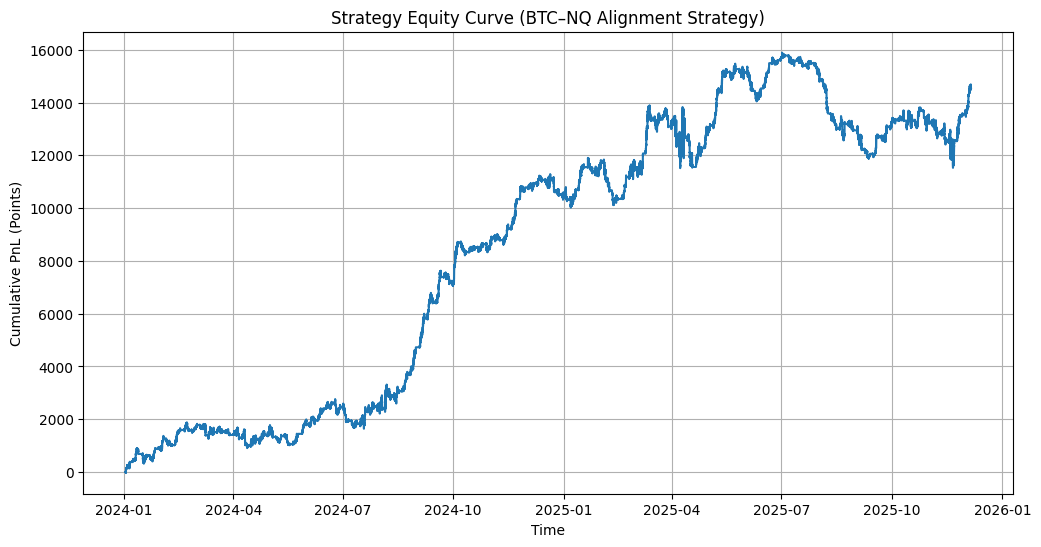

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 1. Prepare trades
# ===============================
equity_trades = trades.copy()

equity_trades['Exit Time'] = pd.to_datetime(equity_trades['Exit Time'])
equity_trades['Points'] = equity_trades['Points'].astype(float)

# Sort by exit time (critical)
equity_trades = equity_trades.sort_values('Exit Time').reset_index(drop=True)

# ===============================
# 2. Build equity curve
# ===============================
equity_trades['Equity'] = equity_trades['Points'].cumsum()

# Optional: starting capital
START_CAPITAL = 0
equity_trades['Equity'] += START_CAPITAL

# ===============================
# 3. Plot equity curve
# ===============================
plt.figure(figsize=(12, 6))
plt.plot(
    equity_trades['Exit Time'],
    equity_trades['Equity'],
    drawstyle='steps-post'
)

plt.title("Strategy Equity Curve (BTC–NQ Alignment Strategy)")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL (Points)")
plt.grid(True)

plt.show()


#### PnL Distribution

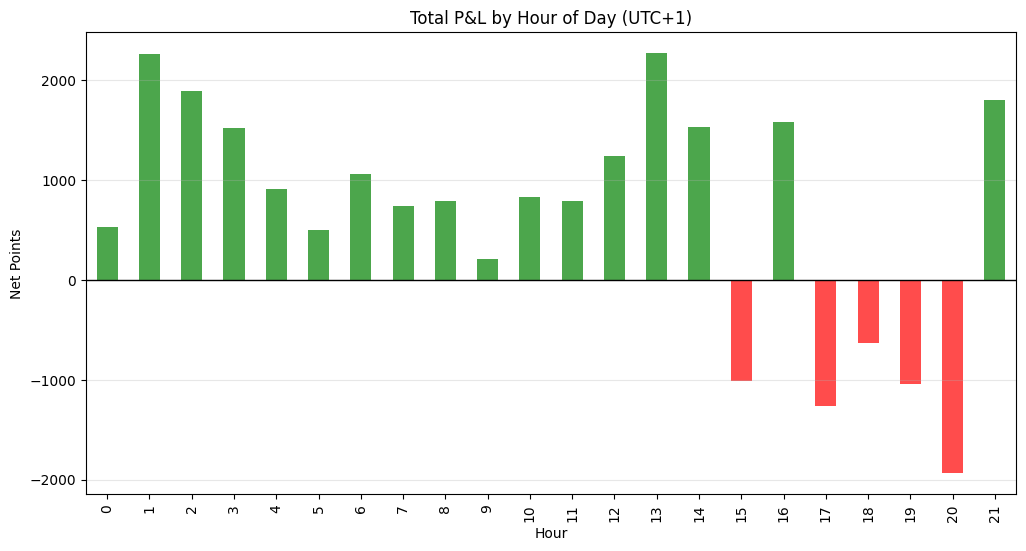

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'Hour' column exists based on entry time
trades['Hour'] = trades['Entry Time'].dt.hour

# Aggregate total PnL per hour
hourly_pnl = trades.groupby('Hour')['Points'].sum()

# Plot hourly PnL
plt.figure(figsize=(12, 6))
colors = np.where(hourly_pnl > 0, 'green', 'red')
hourly_pnl.plot(kind='bar', color=colors, alpha=0.7)
plt.title('Total P&L by Hour of Day (UTC+1)')
plt.ylabel('Net Points')
plt.xlabel('Hour')
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Advanced 3D Trade Surface:

Generating 3D Analysis...


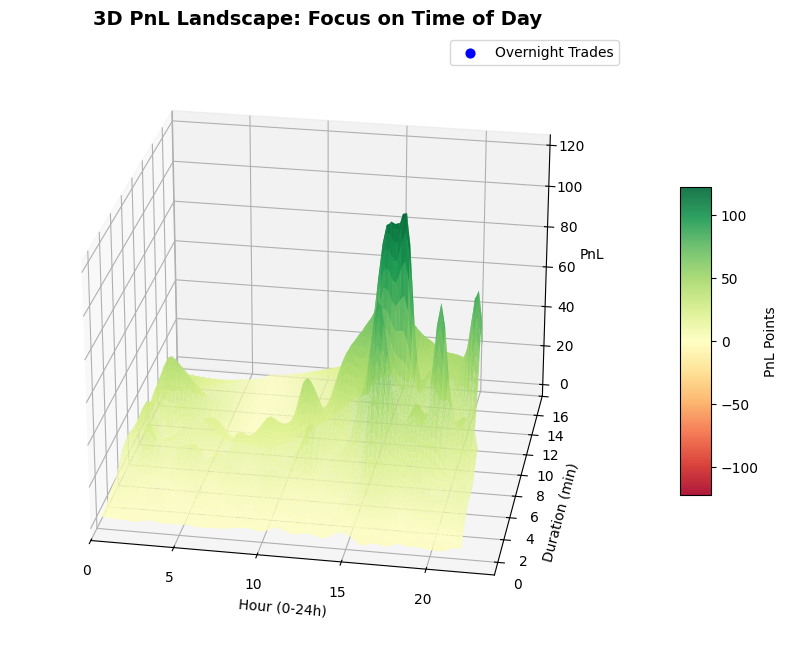

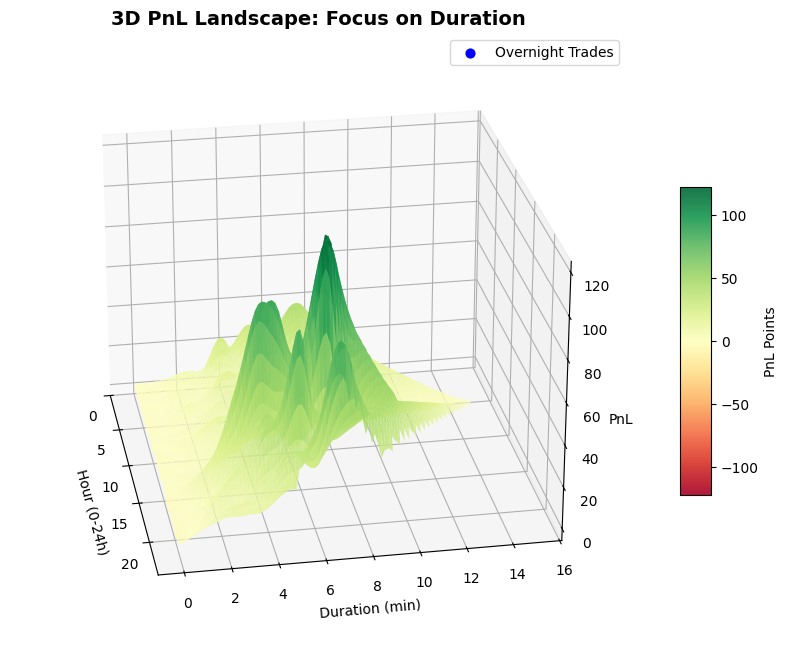

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors
import pandas as pd

# ===============================
# 3D PnL Analysis with Overnight Trades
# ===============================
if 'trades' in locals() and not trades.empty:
    print("Generating 3D Analysis...")

    # Copy and clean
    df_3d = trades.copy()

    # Compute overnight flag
    df_3d['Overnight'] = df_3d['Exit Time'].dt.date > df_3d['Entry Time'].dt.date

    # Filter for duration <= 28 min (optional, adjust as needed)
    df_3d = df_3d[df_3d['Duration (min)'] <= 28]

    if len(df_3d) > 20:
        # Prepare X, Y, Z for 3D surface
        df_3d['Hour_Float'] = df_3d['Entry Time'].dt.hour + df_3d['Entry Time'].dt.minute / 60.0
        x = df_3d['Hour_Float']
        y = df_3d['Duration (min)']
        z = df_3d['Points']

        # Grid for surface
        xi = np.linspace(0, 24, 100)
        yi = np.linspace(0, df_3d['Duration (min)'].max(), 100)
        xi, yi = np.meshgrid(xi, yi)

        # Interpolate and smooth
        zi = griddata((x, y), z, (xi, yi), method='linear')
        mask_nan = np.isnan(zi)
        zi_filled = np.nan_to_num(zi, nan=0.0)
        zi_smooth = gaussian_filter(zi_filled, sigma=1.5)
        zi_smooth[mask_nan] = np.nan

        # Normalize colors around 0
        valid_vals = zi_smooth[~np.isnan(zi_smooth)]
        max_abs = np.max(np.abs(valid_vals)) if len(valid_vals) > 0 else 1.0
        norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

        # --- View 1: Focus on Time ---
        fig1 = plt.figure(figsize=(14, 8))
        ax1 = fig1.add_subplot(111, projection='3d')
        surf1 = ax1.plot_surface(
            xi, yi, zi_smooth,
            cmap='RdYlGn', norm=norm,
            antialiased=True, alpha=0.9, rstride=1, cstride=1, edgecolor='none'
        )
        ax1.set_title('3D PnL Landscape: Focus on Time of Day', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Hour (0-24h)')
        ax1.set_ylabel('Duration (min)')
        ax1.set_zlabel('PnL')
        ax1.set_xlim(0, 24)
        ax1.view_init(elev=25, azim=-80)
        ax1.dist = 9
        fig1.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='PnL Points')

        # Overlay overnight trades as scatter
        overnight = df_3d[df_3d['Overnight']]
        ax1.scatter(
            overnight['Hour_Float'],
            overnight['Duration (min)'],
            overnight['Points'],
            color='blue', s=40, label='Overnight Trades'
        )
        ax1.legend()
        plt.show()

        # --- View 2: Focus on Duration ---
        fig2 = plt.figure(figsize=(14, 8))
        ax2 = fig2.add_subplot(111, projection='3d')
        surf2 = ax2.plot_surface(
            xi, yi, zi_smooth,
            cmap='RdYlGn', norm=norm,
            antialiased=True, alpha=0.9, rstride=1, cstride=1, edgecolor='none'
        )
        ax2.set_title('3D PnL Landscape: Focus on Duration', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Hour (0-24h)')
        ax2.set_ylabel('Duration (min)')
        ax2.set_zlabel('PnL')
        ax2.set_xlim(0, 24)
        ax2.view_init(elev=25, azim=-10)
        ax2.dist = 9
        fig2.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='PnL Points')

        # Overlay overnight trades as scatter
        ax2.scatter(
            overnight['Hour_Float'],
            overnight['Duration (min)'],
            overnight['Points'],
            color='blue', s=40, label='Overnight Trades'
        )
        ax2.legend()
        plt.show()

    else:
        print("Too few trades (< 20) for 3D analysis.")
else:
    print("No trades available for 3D analysis.")


## 3.7 Baseline Strategy Evaluation

### **A. Market Regime Analysis**
- **Non-stationary BTC–NQ relationship:** Correlation varies across market regimes.
- **Event-Driven Synchronization:** Rolling correlations spike (>0.7) around **NY Market Open (15:30 CET)**, confirming high-volume events drive asset synchronization.
- **Golden Hours:** Hourly heatmap identifies **15:00–17:00 CET** as stable positive correlation windows, optimal for cross-asset signals.

### **B. Strategy Performance (Backtest)**
- **Profitability Drivers:** Alpha is mainly captured during high-correlation windows.  
- **Drawdown Periods:** Losses occur when correlation weakens, e.g., London lunch lull (12:00–14:00) and late NY session. 

### **C. Advanced Optimization Insights (3D Analysis)**
- **High-probability sessions:** Most profitable trades cluster in **NY session**, minor cluster at Asian session open (requires more data).  
- **Trade Duration:** Short trades (0–3 min) are mostly unprofitable; filtering these could reduce losses.

## 3.8 Motivation for Machine Learning Enhancement

The backtesting and microstructure analysis highlight opportunities for improving strategy performance using machine learning:

- **Time-Filtering Optimization:** ML models can dynamically identify high-probability trading windows (e.g., "golden hours") instead of using fixed hours.  
- **Feature-Based Signal Enhancement:** Incorporating additional features such as `Rolling_Corr_60m`, Bollinger Bands, volatility measures, or other microstructure indicators can allow ML algorithms to filter low-quality trades and improve predictive accuracy.  
- **Trade Quality Prediction:** ML can help predict which signals are likely to be profitable, reducing the frequency of ultra-short, unprofitable trades.  
- **Adaptive Strategy:** Machine learning enables the strategy to adjust to non-stationary market regimes, capturing evolving correlations between BTC and NQ.
